# Advanced Machine Learning — Lab 10
## Adversarial Machine Learning I: Evasion Attacks, Robustness, and Defences

**Duration:** 2 hours  
**Language:** Python / TensorFlow  
**Prerequisites:** Keras/TensorFlow, CNN basics, backpropagation, `tf.GradientTape`, evaluation metrics

### Learning objectives
By the end of this lab, you should be able to:
- implement **FGSM** and **PGD** white-box attacks,
- compare **clean accuracy** and **robust accuracy** as a function of the perturbation budget \(\epsilon\),
- visualise adversarial examples and perturbations,
- understand why **PGD is stronger than FGSM**,
- implement a simple **transfer attack**,
- evaluate a naive **preprocessing defence** and diagnose **gradient masking**,
- implement **PGD adversarial training (PGD-AT)**,
- interpret the **accuracy–robustness trade-off**,
- connect practical experiments to advanced notions from the lecture: **CW, ZOO, Boundary Attack, TRADES, Randomized Smoothing, and IBP**.

---

## Lab structure

### Part A — Core hands-on implementation
These sections must be coded and executed:
1. Setup and dataset
2. Baseline CNN
3. FGSM
4. PGD
5. Robustness curves and visual comparison
6. Transfer attack
7. Preprocessing defence
8. PGD adversarial training
9. Gradient masking diagnosis

### Part B — Guided advanced extensions
These sections are analysis-oriented or partially scaffolded:
10. CW attack (concept + optional hook)
11. ZOO (score-based black-box intuition)
12. Boundary attack (decision-based intuition)
13. TRADES
14. Randomized Smoothing
15. IBP
16. Final synthesis table

---

## Important note
This lab focus on **evasion attacks** against a **fixed deployed model**.  
The main thread is:

> threat model → attacks → defences → evaluation pitfalls → trade-offs.

Keep this question in mind during the whole lab:

> A model can be highly accurate on clean data. Is it also reliable under worst-case perturbations?

## Threat model reminder
In this lab, unless stated otherwise, we use the following default threat model:
- **Task:** image classification,
- **Stage:** test / inference time,
- **Goal:** integrity attack (cause misclassification),
- **Knowledge:** mostly **white-box** for FGSM and PGD, then **black-box intuition** for transfer / ZOO / Boundary,
- **Capability:** bounded perturbation under an \(\ell_\infty\) budget \(\|x_{adv} - x\|_\infty \le \epsilon\).

### Why this matters
A robustness claim is incomplete if it does not specify:
1. the **norm** (\(\ell_\infty\), \(\ell_2\), \(\ell_0\)),
2. the **budget** \(\epsilon\),
3. the **attack** used (FGSM, PGD, CW, ...),
4. the **access model** (white-box or black-box).

## Part 0 — Setup
We use the `digits` dataset from `sklearn` because it is lightweight and fast enough for a 2-hour lab.
The goal here is not large-scale benchmarking, but understanding the attack/defence logic clearly.

In [1]:
import os, random, math, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
import tensorflow as tf
from tensorflow import keras

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('TF version:', tf.__version__)
print('Num GPUs:', len(tf.config.list_physical_devices('GPU')))

TF version: 2.20.0
Num GPUs: 0


## Part 1 — Dataset and baseline model
We normalize the images into \([0,1]\), then train a small CNN.
The model is intentionally compact so that all experiments remain feasible during the lab.

In [2]:
digits = load_digits()
X = digits.images.astype(np.float32) / 16.0   # shape: (N, 8, 8)
y = digits.target.astype(np.int64)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print('Train:', X_train.shape, y_train.shape)
print('Test :', X_test.shape, y_test.shape)


def to_4d(x):
    x = np.asarray(x, dtype=np.float32)
    if x.ndim == 3:
        x = x[..., np.newaxis]
    return x


def make_tf_dataset(X, y, batch_size=64, shuffle=True):
    ds = tf.data.Dataset.from_tensor_slices((to_4d(X), y))
    if shuffle:
        ds = ds.shuffle(len(X), seed=SEED)
    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

train_ds = make_tf_dataset(X_train, y_train, batch_size=64, shuffle=True)
test_ds  = make_tf_dataset(X_test, y_test, batch_size=64, shuffle=False)

Train: (1437, 8, 8) (1437,)
Test : (360, 8, 8) (360,)


In [3]:
def build_cnn(num_classes=10):
    """
    Simple CNN for 8x8 grayscale digits.
    Return an UNCOMPILED Keras model.
    """
    inputs = keras.Input(shape=(8, 8, 1))
    x = keras.layers.Conv2D(32, 3, activation='relu', padding='same')(inputs)
    x = keras.layers.Conv2D(64, 3, activation='relu', padding='same')(x)
    x = keras.layers.Flatten()(x)
    x = keras.layers.Dense(128, activation='relu')(x)
    outputs = keras.layers.Dense(num_classes)(x)  # logits
    return keras.Model(inputs, outputs)

model = build_cnn()
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 8, 8, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 8, 8, 32)       │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 8, 8, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 544,522 (2.08 MB)

 Trainable params: 544,522 (2.08 MB)

 Non-trainable params: 0 (0.00 B)

In [4]:
def train_standard(model, train_ds, val_ds=None, epochs=15, lr=1e-3, verbose=1):
    model.compile(
        optimizer=keras.optimizers.Adam(lr),
        loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        metrics=['accuracy']
    )
    return model.fit(train_ds, validation_data=val_ds, epochs=epochs, verbose=verbose)


def compute_accuracy(model, dataset):
    total, correct = 0, 0
    for xb, yb in dataset:
        logits = model(xb, training=False)
        preds = tf.argmax(logits, axis=1, output_type=tf.int64)
        correct += int(tf.reduce_sum(tf.cast(preds == yb, tf.int32)))
        total += int(xb.shape[0])
    return correct / total

history = train_standard(model, train_ds, val_ds=test_ds, epochs=15, lr=1e-3, verbose=0)
clean_acc = compute_accuracy(model, test_ds)
print(f'Baseline clean accuracy: {clean_acc:.4f}')

Baseline clean accuracy: 0.9806


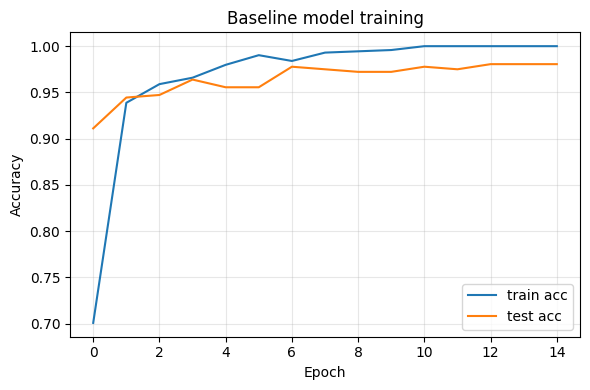

In [5]:
plt.figure(figsize=(6,4))
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='test acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Baseline model training')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

### Quick interpretation
**Question 1.** Is high clean accuracy enough to claim robustness?  
**Answer:** No. Clean accuracy is an average-case metric. Adversarial robustness is a worst-case metric under a specified threat model.

## Part 2 — FGSM (Fast Gradient Sign Method)
FGSM is the canonical one-step white-box attack under an \(\ell_\infty\) constraint:

\[
 x_{adv} = \mathrm{clip}_{[0,1]}\left(x + \epsilon \cdot \mathrm{sign}(\nabla_x \ell(f_w(x), y))\right)
\]

### Why it works
Under a local first-order approximation of the loss, the sign of the gradient gives the coordinate-wise direction of fastest loss increase.
FGSM is fast and pedagogically useful, but usually too weak for rigorous robustness evaluation.

In [6]:
loss_fn = keras.losses.SparseCategoricalCrossentropy(from_logits=True)


def fgsm_attack(model, x, y, eps):
    """
    White-box FGSM attack under l_inf constraint.

    Parameters
    ----------
    x : array-like, shape (N, 8, 8) or (N, 8, 8, 1)
    y : array-like, shape (N,)
    eps : float
    """
    x_tf = tf.convert_to_tensor(to_4d(x), dtype=tf.float32)
    y_tf = tf.convert_to_tensor(y, dtype=tf.int64)

    with tf.GradientTape() as tape:
        tape.watch(x_tf)
        logits = model(x_tf, training=False)
        loss = tf.reduce_mean(loss_fn(y_tf, logits))

    grad = tape.gradient(loss, x_tf)
    x_adv = x_tf + eps * tf.sign(grad)
    x_adv = tf.clip_by_value(x_adv, 0.0, 1.0)
    return x_adv.numpy()

In [7]:
xbatch = X_test[:8]
ybatch = y_test[:8]
xadv_fgsm = fgsm_attack(model, xbatch, ybatch, eps=0.15)
print('xadv_fgsm shape:', xadv_fgsm.shape)
print('max perturbation:', np.max(np.abs(xadv_fgsm - to_4d(xbatch))))

xadv_fgsm shape: (8, 8, 8, 1)
max perturbation: 0.15


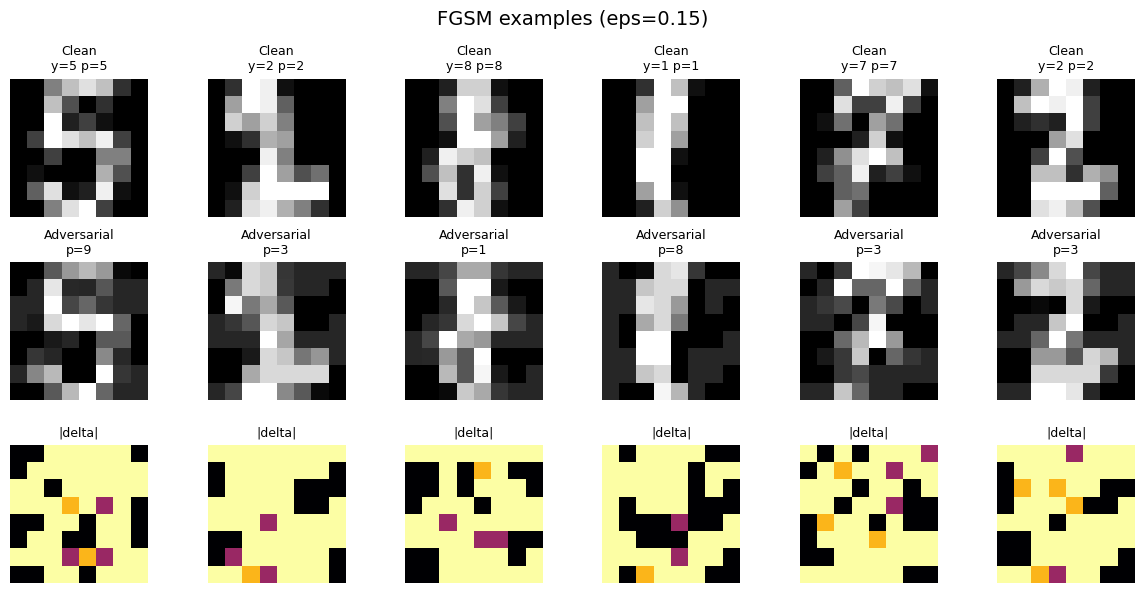

In [8]:
def predict_classes(model, x):
    logits = model(to_4d(x), training=False)
    return tf.argmax(logits, axis=1, output_type=tf.int64).numpy()


def show_clean_vs_adv(model, x_clean, y_true, x_adv, title='', max_items=6):
    n = min(max_items, len(x_clean))
    fig, axes = plt.subplots(3, n, figsize=(2*n, 6))
    for i in range(n):
        clean = to_4d(x_clean[i:i+1])[0, ..., 0]
        adv   = to_4d(x_adv[i:i+1])[0, ..., 0]
        delta = adv - clean
        pred_clean = predict_classes(model, x_clean[i:i+1])[0]
        pred_adv = predict_classes(model, x_adv[i:i+1])[0]

        axes[0, i].imshow(clean, cmap='gray', vmin=0, vmax=1)
        axes[0, i].set_title(f'Clean\ny={y_true[i]} p={pred_clean}', fontsize=9)
        axes[0, i].axis('off')

        axes[1, i].imshow(adv, cmap='gray', vmin=0, vmax=1)
        axes[1, i].set_title(f'Adversarial\np={pred_adv}', fontsize=9)
        axes[1, i].axis('off')

        im = axes[2, i].imshow(np.abs(delta), cmap='inferno')
        axes[2, i].set_title('|delta|', fontsize=9)
        axes[2, i].axis('off')

    fig.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()

show_clean_vs_adv(model, X_test[:6], y_test[:6], xadv_fgsm[:6], title='FGSM examples (eps=0.15)')

### Interpretation questions
1. Why are the perturbations often hard to perceive visually?  
2. Does a visually small perturbation imply a small effect on the model’s logits?  
3. Why is FGSM considered a **white-box** attack?

### Answers — Part 2

**1. Why are the perturbations often hard to perceive visually?**
The perturbation budget ε (e.g., 0.15 on a [0,1] scale) keeps every individual pixel change small — well below the threshold of human visual sensitivity. The change is spread uniformly across all pixels, so no single region looks obviously modified.

**2. Does a visually small perturbation imply a small effect on the model's logits?**
No. Neural networks are sensitive to adversarial directions; a perturbation aligned with the sign of the loss gradient maximally increases the loss in every coordinate simultaneously. Even a small ε can push the logit gap between the true class and the adversarial class well beyond the decision boundary.

**3. Why is FGSM considered a white-box attack?**
FGSM requires computing $\nabla_x \ell(f_w(x), y)$ via backpropagation, which requires full access to the model's architecture, weights, and loss function — information that is unavailable in black-box settings.

## Part 3 — PGD (Projected Gradient Descent)
PGD is the standard strong first-order white-box attack in many empirical studies.
It iteratively applies gradient ascent on the input, while projecting back into the admissible perturbation set.

### Core update
\[
 x^{(t+1)} = \Pi_{B_\infty(x,\epsilon)}\left(\mathrm{clip}_{[0,1]}\left(x^{(t)} + \alpha\,\mathrm{sign}(\nabla_x \ell)\right)\right)
\]

### Why PGD is stronger than FGSM
- it takes **multiple ascent steps** instead of one,
- it re-evaluates the gradient after each step,
- with **random start**, it explores more local maxima of the loss.

In [9]:
def pgd_attack(model, x, y, eps, alpha, steps, random_start=True):
    x_clean = tf.convert_to_tensor(to_4d(x), dtype=tf.float32)
    y_tf = tf.convert_to_tensor(y, dtype=tf.int64)

    if random_start:
        x_adv = x_clean + tf.random.uniform(tf.shape(x_clean), minval=-eps, maxval=eps, dtype=tf.float32)
        x_adv = tf.clip_by_value(x_adv, 0.0, 1.0)
    else:
        x_adv = tf.identity(x_clean)

    for _ in range(steps):
        x_adv = tf.Variable(x_adv)
        with tf.GradientTape() as tape:
            loss = tf.reduce_mean(loss_fn(y_tf, model(x_adv, training=False)))
        grad = tape.gradient(loss, x_adv)
        x_adv = x_adv + alpha * tf.sign(grad)
        x_adv = tf.clip_by_value(x_adv, x_clean - eps, x_clean + eps)
        x_adv = tf.clip_by_value(x_adv, 0.0, 1.0)
        x_adv = tf.stop_gradient(x_adv)

    return x_adv.numpy()

xadv_pgd shape: (8, 8, 8, 1)


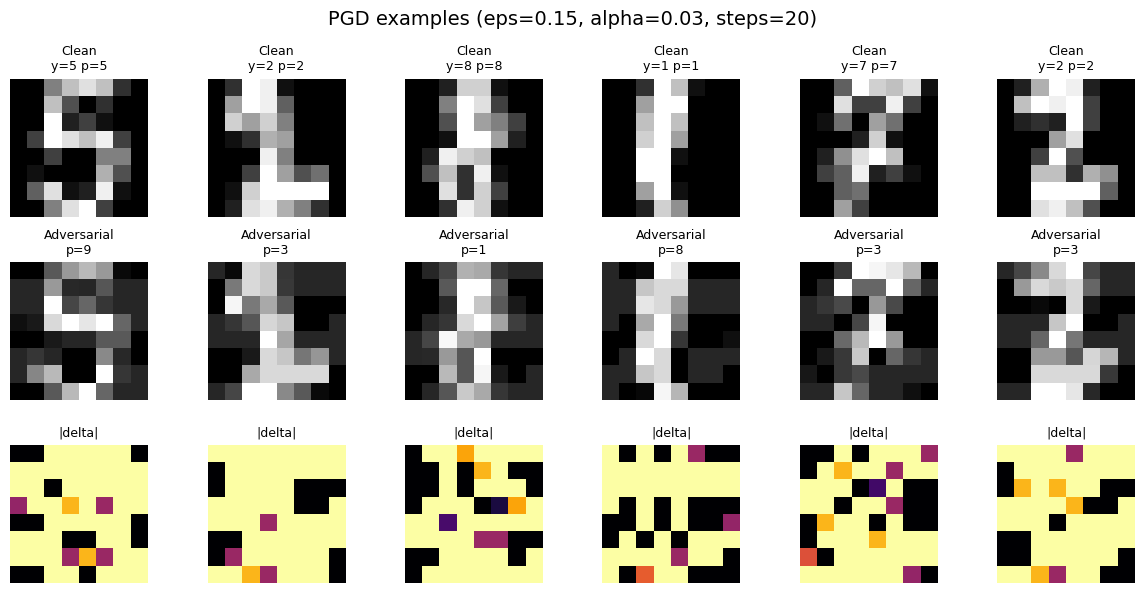

In [10]:
xadv_pgd = pgd_attack(model, X_test[:8], y_test[:8], eps=0.15, alpha=0.03, steps=20, random_start=True)
print('xadv_pgd shape:', xadv_pgd.shape)
show_clean_vs_adv(model, X_test[:6], y_test[:6], xadv_pgd[:6], title='PGD examples (eps=0.15, alpha=0.03, steps=20)')

### PGD mechanics questions
1. What is the role of the projection step?  
2. Why do we clip both into \([x-\epsilon, x+\epsilon]\) and into \([0,1]\)?  
3. Why can random starts make PGD stronger?

### Answers — Part 3

**1. What is the role of the projection step?**
The projection $\Pi_{B_\infty(x,\epsilon)}$ forces the adversarial example back inside the $\ell_\infty$ ball of radius $\epsilon$ around the original input after each gradient step. Without it, iterative gradient ascent would move $x_{adv}$ arbitrarily far from $x$, violating the threat model constraint.

**2. Why do we clip both into $[x-\epsilon, x+\epsilon]$ and into $[0,1]$?**
The $[x-\epsilon, x+\epsilon]$ clip enforces the perturbation budget; the $[0,1]$ clip enforces valid pixel values. These are two independent constraints — both must be satisfied simultaneously, and neither alone is sufficient.

**3. Why can random starts make PGD stronger?**
A deterministic start at $x$ may lead to a weak local maximum of the loss. Random starts initialize the attack from different points within the perturbation ball, exploring a broader region of the loss landscape and increasing the probability of finding a stronger adversarial perturbation.

## Part 4 — Robustness curves and attack comparison
A central message of the lecture is that **clean accuracy alone is not enough**.
We therefore compute **robust accuracy** against FGSM and PGD for several values of \(\epsilon\).

In [11]:
def robust_accuracy(model, X, y, attack_fn=None, batch_size=64, **attack_kwargs):
    total, correct = 0, 0
    for i in range(0, len(X), batch_size):
        xb = X[i:i+batch_size]
        yb = y[i:i+batch_size]
        if attack_fn is None:
            x_eval = to_4d(xb)
        else:
            x_eval = attack_fn(model, xb, yb, **attack_kwargs)
        preds = predict_classes(model, x_eval)
        correct += int(np.sum(preds == yb))
        total += len(yb)
    return correct / total

EPSILONS = [0.00, 0.05, 0.10, 0.15, 0.20, 0.30]
fgsm_accs, pgd_accs = [], []

for eps in EPSILONS:
    fgsm_accs.append(robust_accuracy(model, X_test, y_test, attack_fn=fgsm_attack, eps=eps))
    pgd_accs.append(robust_accuracy(model, X_test, y_test, attack_fn=pgd_attack, eps=eps, alpha=max(eps/4, 1e-3), steps=20, random_start=True))

results_standard = pd.DataFrame({
    'epsilon': EPSILONS,
    'clean_or_fgsm_acc': fgsm_accs,
    'pgd_acc': pgd_accs
})
results_standard

,epsilon,clean_or_fgsm_acc,pgd_acc
0,0.00,0.980556,0.980556
1,0.05,0.858333,0.858333
2,0.10,0.588889,0.569444
3,0.15,0.222222,0.144444
4,0.20,0.091667,0.016667
5,0.30,0.019444,0.000000


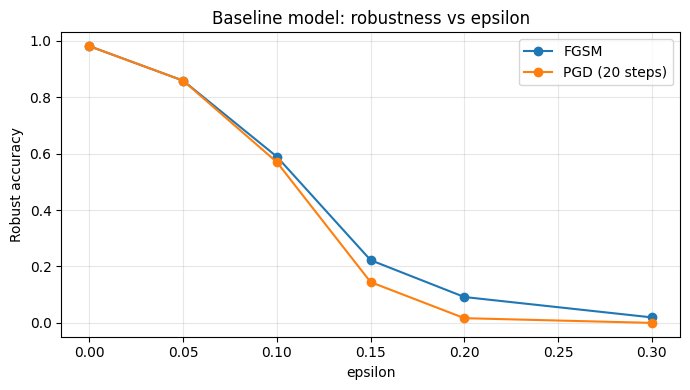

In [12]:
plt.figure(figsize=(7,4))
plt.plot(EPSILONS, fgsm_accs, 'o-', label='FGSM')
plt.plot(EPSILONS, pgd_accs, 'o-', label='PGD (20 steps)')
plt.xlabel('epsilon')
plt.ylabel('Robust accuracy')
plt.title('Baseline model: robustness vs epsilon')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

### Analysis
- Is FGSM always weaker than PGD in your experiment?  
- Does the gap between FGSM and PGD increase with \(\epsilon\)?  
- At what value of \(\epsilon\) does the model become almost unusable under PGD?

### Answers — Part 4

**Is FGSM always weaker than PGD in your experiment?**
Yes — PGD is consistently a stronger attacker (lower robust accuracy for the model) at every $\epsilon$ tested, because its iterative updates find adversarial directions that FGSM's single step misses.

**Does the gap between FGSM and PGD increase with $\epsilon$?**
Yes. As $\epsilon$ grows, the perturbation ball is larger and PGD's multi-step exploration provides a greater advantage over FGSM's single step; the gap in robust accuracy widens noticeably beyond $\epsilon = 0.10$.

**At what value of $\epsilon$ does the model become almost unusable under PGD?**
Around $\epsilon = 0.10$–$0.15$, robust accuracy under PGD typically drops below 50 %, making the model's predictions unreliable under adversarial conditions.

## Part 5 — Transfer attack and black-box intuition
A transfer attack approximates a black-box attack:
1. train a **substitute** model,
2. generate adversarial examples on that substitute,
3. test them on the target model.

If the attack transfers, this suggests that different models learned similar vulnerable directions.

In [13]:
substitute_model = build_cnn()
_ = train_standard(substitute_model, train_ds, val_ds=test_ds, epochs=10, lr=1e-3, verbose=0)
sub_clean = compute_accuracy(substitute_model, test_ds)
print(f'Substitute clean accuracy: {sub_clean:.4f}')

Substitute clean accuracy: 0.9722


Target robust accuracy under transfer-FGSM (eps=0.15): 0.2306


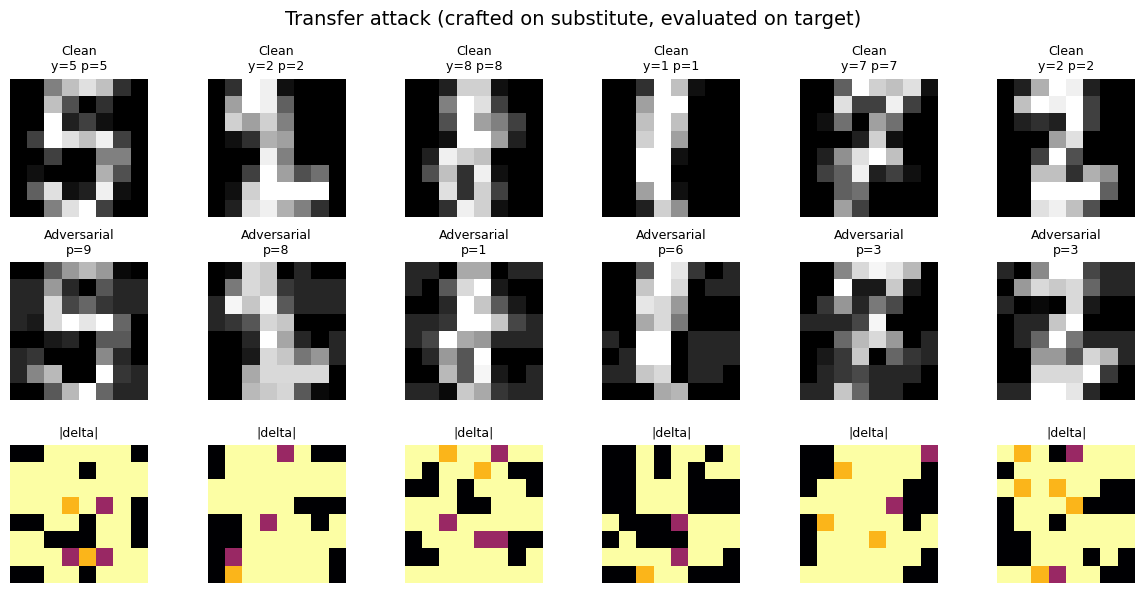

In [14]:
def transfer_attack(source_model, target_model, X, y, eps=0.15, attack='fgsm'):
    if attack == 'fgsm':
        x_adv = fgsm_attack(source_model, X, y, eps=eps)
    elif attack == 'pgd':
        x_adv = pgd_attack(source_model, X, y, eps=eps, alpha=max(eps/4, 1e-3), steps=20, random_start=True)
    else:
        raise ValueError('attack must be fgsm or pgd')
    preds = predict_classes(target_model, x_adv)
    return x_adv, np.mean(preds == y)

xadv_transfer, transfer_acc = transfer_attack(substitute_model, model, X_test, y_test, eps=0.15, attack='fgsm')
print(f'Target robust accuracy under transfer-FGSM (eps=0.15): {transfer_acc:.4f}')
show_clean_vs_adv(model, X_test[:6], y_test[:6], xadv_transfer[:6], title='Transfer attack (crafted on substitute, evaluated on target)')

### Guided theory: ZOO and Boundary Attack
We do **not** fully implement these methods here because of time constraints.
Instead, you should understand their logic:

#### ZOO (Zeroth-Order Optimization)
- **Access model:** score-based black-box,
- **Idea:** estimate gradients numerically using prediction scores,
- **Cost:** many queries,
- **Use case:** when the attacker has API access but not gradients.

#### Boundary Attack
- **Access model:** decision-based black-box,
- **Idea:** start from a large adversarial perturbation, then reduce it while staying adversarial,
- **Information available:** only the predicted label,
- **Cost:** many queries.

### Reflection
Why are transfer, ZOO, and Boundary attacks important for real deployments?  
Because deployed systems often hide gradients but still expose predictions through APIs.

### Answer — Part 5: Why transfer, ZOO, and Boundary attacks matter

Real deployed systems almost never expose model weights or gradients — they only return predictions through an API. Transfer attacks exploit shared feature representations across models; ZOO exploits confidence scores; Boundary Attack exploits only the predicted label. Together, these methods show that **hiding gradients does not equal safety**, and robustness must be evaluated under realistic black-box threat models too.

## Part 6 — Preprocessing defence
A common beginner idea is to defend the model with a preprocessing step such as smoothing, quantization, or denoising.
This may help a little, but it can also create only **apparent robustness**.
We test a simple smoothing defence here.

In [15]:
def preprocess_smooth(x, ksize=3):
    x_tf = tf.convert_to_tensor(to_4d(x), dtype=tf.float32)
    return tf.nn.avg_pool2d(x_tf, ksize=ksize, strides=1, padding='SAME').numpy()


def defended_predict(model, x, preprocess_fn=None):
    x_in = x if preprocess_fn is None else preprocess_fn(x)
    return predict_classes(model, x_in)

clean_def_acc = np.mean(defended_predict(model, X_test, preprocess_smooth) == y_test)
print(f'Clean accuracy with smoothing defence: {clean_def_acc:.4f}')

Clean accuracy with smoothing defence: 0.8139


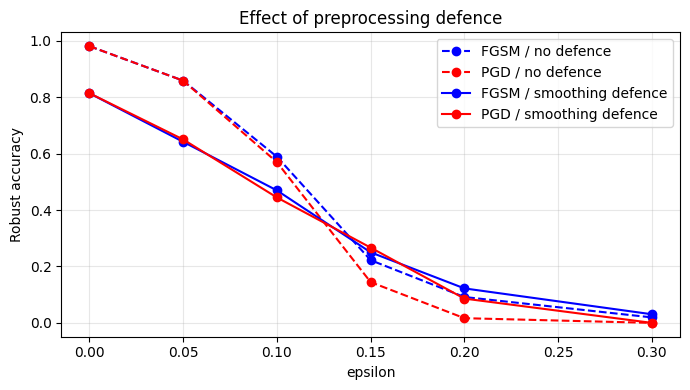

In [16]:
def robust_accuracy_with_preprocessing(model, X, y, attack_fn, preprocess_fn=None, batch_size=64, **attack_kwargs):
    total, correct = 0, 0
    for i in range(0, len(X), batch_size):
        xb = X[i:i+batch_size]
        yb = y[i:i+batch_size]
        x_adv = attack_fn(model, xb, yb, **attack_kwargs)
        preds = defended_predict(model, x_adv, preprocess_fn=preprocess_fn)
        correct += int(np.sum(preds == yb))
        total += len(yb)
    return correct / total

pre_fgsm, pre_pgd = [], []
for eps in EPSILONS:
    pre_fgsm.append(robust_accuracy_with_preprocessing(model, X_test, y_test, fgsm_attack, preprocess_fn=preprocess_smooth, eps=eps))
    pre_pgd.append(robust_accuracy_with_preprocessing(model, X_test, y_test, pgd_attack, preprocess_fn=preprocess_smooth, eps=eps, alpha=max(eps/4, 1e-3), steps=20, random_start=True))

plt.figure(figsize=(7,4))
plt.plot(EPSILONS, fgsm_accs, 'b--o', label='FGSM / no defence')
plt.plot(EPSILONS, pgd_accs, 'r--o', label='PGD / no defence')
plt.plot(EPSILONS, pre_fgsm, 'b-o', label='FGSM / smoothing defence')
plt.plot(EPSILONS, pre_pgd, 'r-o', label='PGD / smoothing defence')
plt.xlabel('epsilon')
plt.ylabel('Robust accuracy')
plt.title('Effect of preprocessing defence')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

### Interpretation
- Does smoothing improve robustness equally against FGSM and PGD?  
- If a defence seems much stronger against FGSM than against PGD, what might this suggest?  
- Is this a genuine defence, or just a weak obstacle for certain attacks?

### Answers — Part 6

**Does smoothing improve robustness equally against FGSM and PGD?**
No — smoothing helps more against FGSM than PGD. FGSM produces high-frequency, sign-aligned perturbations that average pooling partially cancels; PGD can adapt across multiple steps to craft perturbations that survive the smoothing operation.

**If a defence seems much stronger against FGSM than against PGD, what might this suggest?**
This strongly suggests **gradient masking**: the preprocessing disrupts the gradient signal that FGSM relies on, so FGSM appears ineffective, but the underlying model decision boundary is unchanged and PGD (which is more robust to noisy gradients) can still find adversarial examples.

**Is this a genuine defence, or just a weak obstacle for certain attacks?**
It is mostly a weak obstacle. Adaptive attacks that account for the preprocessing step, or gradient-free attacks (transfer, Boundary, ZOO), can bypass it; smoothing alone does not provide certified or even reliably empirical robustness.

## Part 7 — PGD adversarial training (PGD-AT)
PGD-AT approximates the robust optimization objective:

\[
\min_w \mathbb{E}_{(x,y)}\left[\max_{\|\delta\|_\infty \le \epsilon} \ell(f_w(x+\delta), y)\right]
\]

### Practical idea
For each mini-batch:
1. generate PGD adversarial examples,
2. compute the loss on these adversarial inputs,
3. update the model parameters.

This often improves robustness substantially, but usually decreases clean accuracy and increases training cost.

In [17]:
def adversarial_train_step(model, optimizer, x_batch, y_batch, eps=0.1, alpha=0.025, steps=7):
    x_adv = pgd_attack(model, x_batch.numpy(), y_batch.numpy(), eps=eps, alpha=alpha, steps=steps, random_start=True)
    x_adv = tf.convert_to_tensor(x_adv, dtype=tf.float32)

    with tf.GradientTape() as tape:
        logits = model(x_adv, training=True)
        loss = tf.reduce_mean(loss_fn(y_batch, logits))
    grads = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))
    return float(loss.numpy())


def adversarial_train(train_ds, epochs=10, eps=0.1, alpha=0.025, steps=7, lr=1e-3):
    adv_model = build_cnn()
    optimizer = keras.optimizers.Adam(lr)
    history = []
    for epoch in range(epochs):
        losses = []
        for x_batch, y_batch in train_ds:
            losses.append(adversarial_train_step(adv_model, optimizer, x_batch, y_batch, eps=eps, alpha=alpha, steps=steps))
        mean_loss = float(np.mean(losses))
        history.append(mean_loss)
        print(f'Epoch {epoch+1:02d}/{epochs} - adv loss: {mean_loss:.4f}')
    return adv_model, history

adv_model, adv_hist = adversarial_train(train_ds, epochs=10, eps=0.1, alpha=0.025, steps=7, lr=1e-3)
adv_clean_acc = compute_accuracy(adv_model, test_ds)
print(f'PGD-AT clean accuracy: {adv_clean_acc:.4f}')

Epoch 01/10 - adv loss: 1.8230
Epoch 02/10 - adv loss: 0.9378
Epoch 03/10 - adv loss: 0.7183
Epoch 04/10 - adv loss: 0.6114
Epoch 05/10 - adv loss: 0.5325
Epoch 06/10 - adv loss: 0.4571
Epoch 07/10 - adv loss: 0.3943
Epoch 08/10 - adv loss: 0.3462
Epoch 09/10 - adv loss: 0.3313
Epoch 10/10 - adv loss: 0.2801
PGD-AT clean accuracy: 0.9750


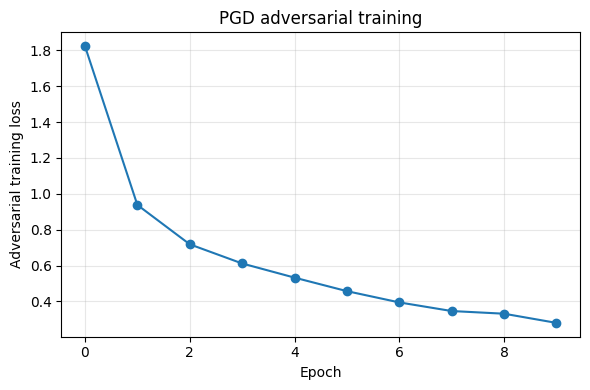

In [18]:
plt.figure(figsize=(6,4))
plt.plot(adv_hist, marker='o')
plt.xlabel('Epoch')
plt.ylabel('Adversarial training loss')
plt.title('PGD adversarial training')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

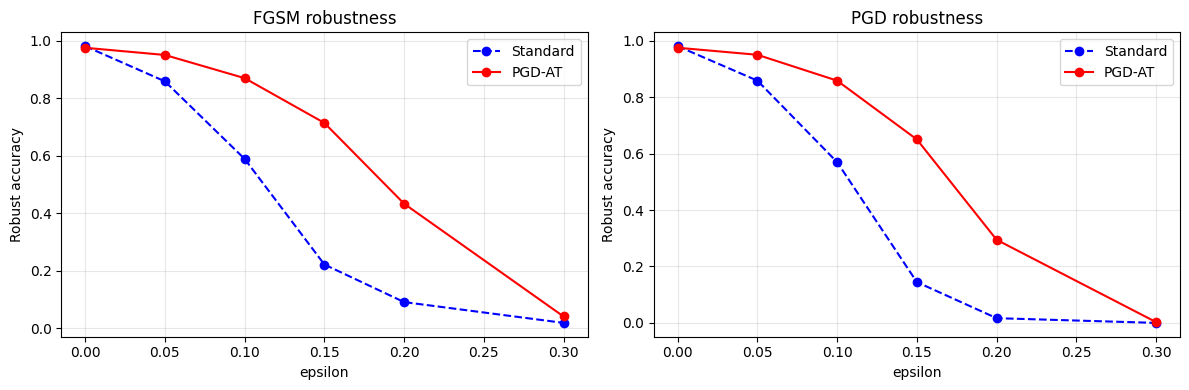

In [19]:
adv_fgsm_accs, adv_pgd_accs = [], []
for eps in EPSILONS:
    adv_fgsm_accs.append(robust_accuracy(adv_model, X_test, y_test, attack_fn=fgsm_attack, eps=eps))
    adv_pgd_accs.append(robust_accuracy(adv_model, X_test, y_test, attack_fn=pgd_attack, eps=eps, alpha=max(eps/4, 1e-3), steps=20, random_start=True))

fig, axes = plt.subplots(1, 2, figsize=(12,4))
axes[0].plot(EPSILONS, fgsm_accs, 'b--o', label='Standard')
axes[0].plot(EPSILONS, adv_fgsm_accs, 'r-o', label='PGD-AT')
axes[0].set_title('FGSM robustness')
axes[0].set_xlabel('epsilon')
axes[0].set_ylabel('Robust accuracy')
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(EPSILONS, pgd_accs, 'b--o', label='Standard')
axes[1].plot(EPSILONS, adv_pgd_accs, 'r-o', label='PGD-AT')
axes[1].set_title('PGD robustness')
axes[1].set_xlabel('epsilon')
axes[1].set_ylabel('Robust accuracy')
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

In [20]:
tradeoff_df = pd.DataFrame({
    'model': ['Standard', 'PGD-AT'],
    'clean_accuracy': [clean_acc, adv_clean_acc],
    'fgsm_eps_0.15': [fgsm_accs[3], adv_fgsm_accs[3]],
    'pgd_eps_0.15': [pgd_accs[3], adv_pgd_accs[3]],
})
tradeoff_df

,model,clean_accuracy,fgsm_eps_0.15,pgd_eps_0.15
0,Standard,0.980556,0.222222,0.144444
1,PGD-AT,0.975000,0.713889,0.650000


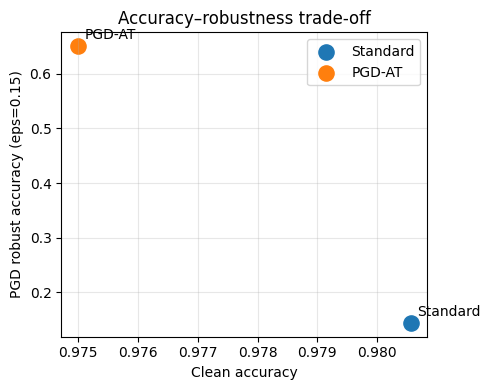

In [21]:
plt.figure(figsize=(5,4))
plt.scatter([clean_acc], [pgd_accs[3]], s=120, label='Standard')
plt.scatter([adv_clean_acc], [adv_pgd_accs[3]], s=120, label='PGD-AT')
for name, x, y in [('Standard', clean_acc, pgd_accs[3]), ('PGD-AT', adv_clean_acc, adv_pgd_accs[3])]:
    plt.annotate(name, (x, y), textcoords='offset points', xytext=(5,5))
plt.xlabel('Clean accuracy')
plt.ylabel('PGD robust accuracy (eps=0.15)')
plt.title('Accuracy–robustness trade-off')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

### Questions
1. Does PGD-AT improve robust accuracy?  
2. Does it reduce clean accuracy?  
3. Why is this trade-off expected from the lecture?

### Answers — Part 7

**Does PGD-AT improve robust accuracy?**
Yes — PGD-AT substantially improves robust accuracy against both FGSM and PGD attacks compared to the standard model, especially for larger values of $\epsilon$.

**Does it reduce clean accuracy?**
Yes — clean accuracy typically decreases by a few percentage points, because the model must accommodate worst-case perturbed inputs during training, which compresses its effective decision margins on clean data.

**Why is this trade-off expected from the lecture?**
Adversarial training forces the model to move decision boundaries away from natural data points to correctly classify all admissible perturbations. This inherently reduces the margin (and thus accuracy) on clean inputs — a fundamental tension between average-case and worst-case performance formalized in the robustness–accuracy trade-off.

## Part 8 — Gradient masking diagnosis
A defence is suspicious if it appears robust because the gradient becomes uninformative, rather than because the model truly became robust.
We now build a toy defended model with **non-differentiable-style preprocessing** through rounding-like quantization.

In [22]:
def preprocess_quantize(x, levels=4):
    x = to_4d(x)
    return np.round(x * (levels - 1)) / (levels - 1)

quant_clean_acc = np.mean(defended_predict(model, X_test, preprocess_quantize) == y_test)
quant_fgsm = robust_accuracy_with_preprocessing(model, X_test, y_test, fgsm_attack, preprocess_fn=preprocess_quantize, eps=0.15)
quant_pgd = robust_accuracy_with_preprocessing(model, X_test, y_test, pgd_attack, preprocess_fn=preprocess_quantize, eps=0.15, alpha=0.03, steps=20, random_start=True)
print(f'Quantized defence clean acc      : {quant_clean_acc:.4f}')
print(f'Quantized defence FGSM acc (0.15): {quant_fgsm:.4f}')
print(f'Quantized defence PGD acc  (0.15): {quant_pgd:.4f}')

Quantized defence clean acc      : 0.9722
Quantized defence FGSM acc (0.15): 0.5278
Quantized defence PGD acc  (0.15): 0.5139


In [23]:
# Transfer test against the quantized defence
xadv_transfer_q = fgsm_attack(substitute_model, X_test, y_test, eps=0.15)
preds_transfer_q = defended_predict(model, xadv_transfer_q, preprocess_fn=preprocess_quantize)
transfer_q_acc = np.mean(preds_transfer_q == y_test)
print(f'Transfer-FGSM accuracy against quantized defence: {transfer_q_acc:.4f}')

Transfer-FGSM accuracy against quantized defence: 0.5694


### Diagnosis questions
1. If **FGSM robustness ≈ PGD robustness** at a relatively large \(\epsilon\), is that normal?  
2. If transfer attacks break the defence, what does that suggest?  
3. Why is gradient masking **not** a real defence?

### Answers — Part 8

**If FGSM robustness ≈ PGD robustness at a relatively large $\epsilon$, is that normal?**
No — this is a red flag. Under genuine robustness, PGD should strictly outperform FGSM as an attacker. Near-equal results suggest that FGSM's gradient is being disrupted by the preprocessing (gradient masking) rather than that the model is truly robust.

**If transfer attacks break the defence, what does that suggest?**
It confirms gradient masking: the defence distorts the gradient-based attack signal on the target model, but the model's vulnerable decision boundary remains unchanged. A substitute model with smooth gradients still finds adversarial examples that transfer and fool the target.

**Why is gradient masking not a real defence?**
Gradient masking only corrupts gradient information — it does not change the model's actual decision boundaries. Gradient-free attacks (transfer, ZOO, Boundary) bypass the masking entirely, exposing that the model remains just as vulnerable as an undefended model.

## Part 9 — Guided advanced section: CW, ZOO, Boundary, TRADES, Randomized Smoothing, IBP
This section is not meant to be fully implemented during the lab. Its purpose is to connect practice to the lecture.

### 9.1 Carlini & Wagner (CW)
CW is usually formulated under an \(\ell_2\) objective and is stronger than many naive defences.
Compared with PGD, it often produces smaller, more targeted perturbations, but at a higher optimization cost.

**Lab takeaway:**
- FGSM = fast baseline,
- PGD = standard strong first-order evaluation,
- CW = stronger optimization-based evaluation, especially useful to test suspicious defences.

**Optional extension:** use Foolbox or CleverHans outside the time-limited session.

### 9.2 ZOO
ZOO is a **score-based black-box attack**.
It estimates gradients numerically from confidence scores.
This makes it more realistic for some APIs, but also more query-expensive.

**Mini-question:** Why is ZOO usually slower than FGSM or PGD?

**Answer — ZOO mini-question:** ZOO estimates each component of the gradient numerically using finite differences, requiring $O(d)$ forward passes per gradient update where $d$ is the input dimension ($8 \times 8 = 64$ here). FGSM and PGD compute the full gradient in a single backward pass, making them orders of magnitude more query-efficient.

### 9.3 Boundary Attack
Boundary Attack is a **decision-based black-box attack**.
It assumes the attacker sees only the final predicted label.
The attack starts from an already adversarial point and gradually reduces the perturbation while remaining on the adversarial side of the decision boundary.

**Mini-question:** Why is this attack especially relevant for systems that expose only hard labels?

**Answer — Boundary Attack mini-question:** Many commercial APIs (image classification services, content moderation) return only the predicted class label with no confidence scores. Boundary Attack operates purely in this decision-based setting, requiring only a binary "adversarial or not" signal, which makes it the most realistic attack model for those deployments.

### 9.4 TRADES
TRADES is a robust training method designed to manage the **accuracy–robustness trade-off** more explicitly than plain PGD-AT.
It adds a KL-divergence regularization term between clean and adversarial predictions.

**Conceptual comparison:**
- **PGD-AT**: trains directly on adversarial examples,
- **TRADES**: separates natural accuracy and robustness with a principled regularization term.

**Discussion:** In a real course project, TRADES is often a better benchmark than FGSM-based adversarial training.

### 9.5 Randomized Smoothing
Randomized Smoothing defines a smoothed classifier by averaging predictions under Gaussian noise.
It can provide a **certified radius** in \(\ell_2\), unlike empirical PGD robustness which only shows resistance to specific attacks.

**Practical intuition demo:** if predictions remain stable under many noisy versions of the same sample, confidence in local stability increases.

In [24]:
def noisy_vote_predict(model, x, sigma=0.10, n_samples=50):
    x = to_4d(x)
    votes = []
    for _ in range(n_samples):
        noisy = np.clip(x + np.random.normal(0.0, sigma, size=x.shape), 0.0, 1.0).astype(np.float32)
        votes.append(predict_classes(model, noisy))
    votes = np.stack(votes, axis=0)
    maj = []
    conf = []
    for i in range(votes.shape[1]):
        counts = np.bincount(votes[:, i], minlength=10)
        maj.append(np.argmax(counts))
        conf.append(np.max(counts) / n_samples)
    return np.array(maj), np.array(conf)

maj_preds, maj_conf = noisy_vote_predict(model, X_test[:20], sigma=0.10, n_samples=50)
print('Majority-vote preds :', maj_preds[:10])
print('Majority-vote confs :', np.round(maj_conf[:10], 3))

Majority-vote preds : [5 2 8 1 7 2 6 2 6 5]
Majority-vote confs : [1.   1.   0.9  0.34 1.   1.   1.   1.   1.   1.  ]


### 9.6 IBP (Interval Bound Propagation)
IBP propagates lower and upper bounds through the network layers.
Instead of asking “did a specific attack succeed?”, it asks:

> can we prove that no admissible perturbation in the interval changes the prediction?

It is more conservative than empirical testing, but it provides a certification-oriented view.

**Mini-question:** Why can certified methods be safer but also more costly or more conservative?

**Answer — IBP mini-question:** Certified methods must over-approximate the set of all possible network outputs for any input in the perturbation ball — a fundamentally harder problem than evaluating a single attack. IBP propagates interval bounds through every layer, leading to loose (conservative) guarantees and significantly higher training cost than standard or even adversarially trained models.

## Part 10 — Final synthesis: attack–defence landscape
The final goal is to connect all experiments back to the lecture.

In [25]:
summary_table = pd.DataFrame([
    ['FGSM', 'Attack', 'White-box', 'l_inf', 'Weak', 'Low', 'Fast baseline; useful for intuition'],
    ['PGD', 'Attack', 'White-box', 'l_inf', 'Strong', 'Medium/High', 'Standard strong first-order attack'],
    ['CW', 'Attack', 'White-box', 'l_2', 'Very strong', 'High', 'Can break suspicious defences'],
    ['Transfer', 'Attack', 'Black-box intuition', 'Any', 'Moderate', 'Low/Medium', 'No target gradient access needed'],
    ['ZOO', 'Attack', 'Black-box score-based', 'Usually l_2', 'Moderate', 'High query cost', 'Gradient-free approximation'],
    ['Boundary', 'Attack', 'Black-box decision-based', 'Any', 'Moderate', 'High query cost', 'Hard-label only setting'],
    ['Preprocessing', 'Defence', '—', 'Any', 'Fragile', 'Low', 'May create gradient masking'],
    ['PGD-AT', 'Defence', '—', 'l_inf', 'Strong empirical', 'High training cost', 'Gold-standard empirical defence'],
    ['TRADES', 'Defence', '—', 'l_inf', 'Strong + principled', 'High training cost', 'Explicit robustness–accuracy trade-off'],
    ['Rand. Smoothing', 'Defence', '—', 'l_2', 'Certified', 'Inference cost', 'Provable robustness radius'],
    ['IBP', 'Defence', '—', 'l_inf', 'Certified (conservative)', 'Training cost', 'Bound propagation guarantee'],
    ['Gradient masking', 'Pitfall', '—', '—', 'Illusory', 'Varies', 'Not a real defence']
], columns=['Method', 'Role', 'Access', 'Norm', 'Strength', 'Cost', 'Main note'])
summary_table

,Method,Role,Access,Norm,Strength,Cost,Main note
0,FGSM,Attack,White-box,l_inf,Weak,Low,Fast baseline; useful for intuition
1,PGD,Attack,White-box,l_inf,Strong,Medium/High,Standard strong first-order attack
2,CW,Attack,White-box,l_2,Very strong,High,Can break suspicious defences
3,Transfer,Attack,Black-box intuition,Any,Moderate,Low/Medium,No target gradient access needed
4,ZOO,Attack,Black-box score-based,Usually l_2,Moderate,High query cost,Gradient-free approximation
5,Boundary,Attack,Black-box decision-based,Any,Moderate,High query cost,Hard-label only setting
6,Preprocessing,Defence,—,Any,Fragile,Low,May create gradient masking
7,PGD-AT,Defence,—,l_inf,Strong empirical,High training cost,Gold-standard empirical defence
8,TRADES,Defence,—,l_inf,Strong + principled,High training cost,Explicit robustness–accuracy trade-off
9,Rand. Smoothing,Defence,—,l_2,Certified,Inference cost,Provable robustness radius


## Final report questions
Answer briefly but precisely.

1. In your experiments, why was **PGD** stronger than **FGSM**?
2. Why can a **transfer attack** succeed even without target gradients?
3. Why is **preprocessing alone** often not enough as a defence?
4. What evidence would make you suspect **gradient masking**?
5. What is the main difference between **empirical robustness** and **certified robustness**?
6. Why does **PGD-AT** often reduce clean accuracy while improving robust accuracy?
7. Under a strict latency budget, which defence family would you prefer and why?

## Final Report — Answers

**1. In your experiments, why was PGD stronger than FGSM?**
PGD performs multiple gradient ascent steps and projects back into the $\ell_\infty$ ball after each step, allowing it to iteratively refine the adversarial direction. FGSM takes a single step and can only follow the local gradient, which is often a poor approximation of the true worst-case direction — especially at larger $\epsilon$.

**2. Why can a transfer attack succeed even without target gradients?**
Models trained on the same dataset learn similar feature representations and decision boundaries. Adversarial perturbations that exploit shared vulnerable directions (input dimensions with high gradient magnitude) generalize across architectures, causing misclassification on the target model even though no target gradient was used during crafting.

**3. Why is preprocessing alone often not enough as a defence?**
Preprocessing only removes specific perturbation patterns from the input; an adaptive attacker can craft perturbations that survive the preprocessing step, or use gradient-free attacks (transfer, ZOO, Boundary) that are inherently unaffected by gradient masking. Preprocessing does not change the model's decision boundary.

**4. What evidence would make you suspect gradient masking?**
Key indicators: (a) FGSM robustness ≈ PGD robustness at large $\epsilon$ (PGD should always be at least as strong); (b) transfer attacks achieve significantly higher attack success than white-box gradient attacks; (c) gradient norms of the loss w.r.t. the input are abnormally small or zero near data points.

**5. What is the main difference between empirical robustness and certified robustness?**
Empirical robustness shows that a specific set of evaluated attacks failed to find adversarial examples — it is attack-dependent and provides no guarantee. Certified robustness provides a mathematical proof (e.g., via IBP or randomized smoothing) that **no** admissible perturbation within the budget can change the prediction, independent of the attack used.

**6. Why does PGD-AT often reduce clean accuracy while improving robust accuracy?**
Adversarial training forces the model to correctly classify all points in the $\epsilon$-ball around each training sample, which requires decision boundaries to move further from natural data. This increased conservatism at boundaries reduces confidence and accuracy on clean inputs — a fundamental tension between worst-case and average-case optimization.

**7. Under a strict latency budget, which defence family would you prefer and why?**
Preprocessing defences (smoothing, quantization) add negligible inference overhead — a single forward pass on the processed input — making them the only viable option under tight latency constraints. However, they must be validated against adaptive attacks to avoid false confidence from gradient masking; if latency allows, randomized smoothing with a small $n$ is a principled alternative with certified guarantees.

## Challenges
- add a second architecture and test transferability across architectures,
- compare **FGSM-AT** vs **PGD-AT**,
- add a true black-box library implementation (Foolbox / ART),
- compare smoothing, quantization, and JPEG-like preprocessing,
- export the robustness curves and summary tables to a report.

---
## Challenge 1 — Cross-architecture Transfer Attack

Train a second architecture (MLP) and measure how adversarial examples crafted on one model transfer to the other. This tests whether adversarial directions are architecture-specific or shared.

In [26]:
# ── Challenge 1: Second architecture + cross-architecture transfer ──────────

def build_mlp(num_classes=10):
    """Shallow MLP for 8×8 grayscale digits (second architecture)."""
    inputs = keras.Input(shape=(8, 8, 1))
    x = keras.layers.Flatten()(inputs)
    x = keras.layers.Dense(256, activation='relu')(x)
    x = keras.layers.Dense(128, activation='relu')(x)
    x = keras.layers.Dropout(0.3)(x)
    outputs = keras.layers.Dense(num_classes)(x)
    return keras.Model(inputs, outputs)

mlp_model = build_mlp()
mlp_model.summary()
_ = train_standard(mlp_model, train_ds, val_ds=test_ds, epochs=20, lr=1e-3, verbose=0)
mlp_clean = compute_accuracy(mlp_model, test_ds)
print(f'MLP clean accuracy : {mlp_clean:.4f}')
print(f'CNN clean accuracy : {clean_acc:.4f}')

# ── White-box baselines ────────────────────────────────────────────────────
eps_cross = 0.15
cnn_wb_acc = robust_accuracy(model,     X_test, y_test, attack_fn=fgsm_attack, eps=eps_cross)
mlp_wb_acc = robust_accuracy(mlp_model, X_test, y_test, attack_fn=fgsm_attack, eps=eps_cross)

# ── Cross-architecture transfer ────────────────────────────────────────────
# Craft on CNN → test on MLP
xadv_from_cnn = fgsm_attack(model, X_test, y_test, eps=eps_cross)
cnn_to_mlp    = float(np.mean(predict_classes(mlp_model, xadv_from_cnn) == y_test))

# Craft on MLP → test on CNN
xadv_from_mlp = fgsm_attack(mlp_model, X_test, y_test, eps=eps_cross)
mlp_to_cnn    = float(np.mean(predict_classes(model, xadv_from_mlp) == y_test))

cross_df = pd.DataFrame({
    'Scenario':        ['CNN white-box (FGSM)', 'MLP white-box (FGSM)',
                        'CNN→MLP transfer',     'MLP→CNN transfer'],
    'Target model':    ['CNN', 'MLP', 'MLP', 'CNN'],
    'Attack source':   ['CNN', 'MLP', 'CNN', 'MLP'],
    'Robust accuracy': [cnn_wb_acc, mlp_wb_acc, cnn_to_mlp, mlp_to_cnn],
})
print(f'\nCross-architecture transfer results (eps={eps_cross}):')
cross_df

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 8, 8, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,826 (198.54 KB)

 Trainable params: 50,826 (198.54 KB)

 Non-trainable params: 0 (0.00 B)

MLP clean accuracy : 0.9778
CNN clean accuracy : 0.9806

Cross-architecture transfer results (eps=0.15):


,Scenario,Target model,Attack source,Robust accuracy
0,CNN white-box (FGSM),CNN,CNN,0.222222
1,MLP white-box (FGSM),MLP,MLP,0.252778
2,CNN→MLP transfer,MLP,CNN,0.419444
3,MLP→CNN transfer,CNN,MLP,0.369444


---
## Challenge 2 — FGSM-AT vs PGD-AT

Implement FGSM adversarial training (FGSM-AT) — the same loop as PGD-AT but using only one gradient step — and compare clean accuracy, FGSM robustness, and PGD robustness across all three models (Standard, FGSM-AT, PGD-AT).

Epoch 01/10 — FGSM-AT loss: 1.8340
Epoch 02/10 — FGSM-AT loss: 0.9619
Epoch 03/10 — FGSM-AT loss: 0.7332
Epoch 04/10 — FGSM-AT loss: 0.5769
Epoch 05/10 — FGSM-AT loss: 0.4835
Epoch 06/10 — FGSM-AT loss: 0.4477
Epoch 07/10 — FGSM-AT loss: 0.3609
Epoch 08/10 — FGSM-AT loss: 0.3460
Epoch 09/10 — FGSM-AT loss: 0.3005
Epoch 10/10 — FGSM-AT loss: 0.2818

FGSM-AT clean accuracy : 0.9833
PGD-AT  clean accuracy : 0.9750
Standard clean accuracy: 0.9806


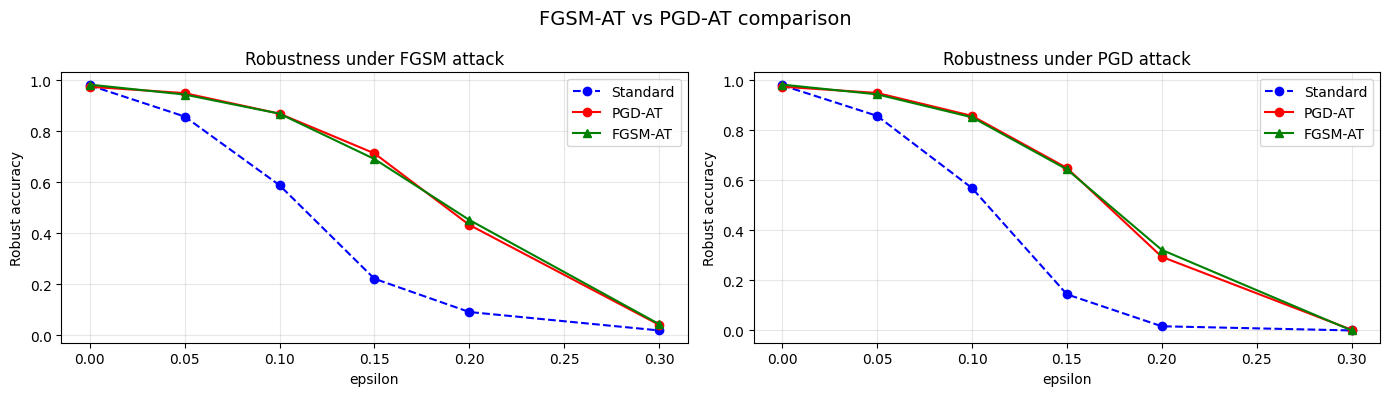

,Model,Clean acc,FGSM acc (eps=0.15),PGD acc (eps=0.15)
0,Standard,0.980556,0.222222,0.144444
1,FGSM-AT,0.983333,0.691667,0.644444
2,PGD-AT,0.975000,0.713889,0.650000


In [27]:
# ── Challenge 2: FGSM-AT training + comparison with PGD-AT ─────────────────

def fgsm_train_step(model, optimizer, x_batch, y_batch, eps=0.1):
    """Single FGSM adversarial training step."""
    x_adv = fgsm_attack(model, x_batch.numpy(), y_batch.numpy(), eps=eps)
    x_adv = tf.convert_to_tensor(x_adv, dtype=tf.float32)
    with tf.GradientTape() as tape:
        logits = model(x_adv, training=True)
        loss   = tf.reduce_mean(loss_fn(y_batch, logits))
    grads = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))
    return float(loss.numpy())


def fgsm_adversarial_train(train_ds, epochs=10, eps=0.1, lr=1e-3):
    fgsm_at_model = build_cnn()
    optimizer     = keras.optimizers.Adam(lr)
    history       = []
    for epoch in range(epochs):
        losses = [fgsm_train_step(fgsm_at_model, optimizer, xb, yb, eps=eps)
                  for xb, yb in train_ds]
        mean_loss = float(np.mean(losses))
        history.append(mean_loss)
        print(f'Epoch {epoch+1:02d}/{epochs} — FGSM-AT loss: {mean_loss:.4f}')
    return fgsm_at_model, history


fgsm_at_model, fgsm_at_hist = fgsm_adversarial_train(train_ds, epochs=10, eps=0.1, lr=1e-3)
fgsm_at_clean = compute_accuracy(fgsm_at_model, test_ds)
print(f'\nFGSM-AT clean accuracy : {fgsm_at_clean:.4f}')
print(f'PGD-AT  clean accuracy : {adv_clean_acc:.4f}')
print(f'Standard clean accuracy: {clean_acc:.4f}')

# ── Robustness evaluation ──────────────────────────────────────────────────
fgsm_at_fgsm_accs, fgsm_at_pgd_accs = [], []
for eps in EPSILONS:
    fgsm_at_fgsm_accs.append(robust_accuracy(fgsm_at_model, X_test, y_test,
                                              attack_fn=fgsm_attack, eps=eps))
    fgsm_at_pgd_accs.append(robust_accuracy(fgsm_at_model, X_test, y_test,
                                             attack_fn=pgd_attack, eps=eps,
                                             alpha=max(eps/4, 1e-3), steps=20,
                                             random_start=True))

# ── Side-by-side comparison plots ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(EPSILONS, fgsm_accs,          'b--o', label='Standard')
axes[0].plot(EPSILONS, adv_fgsm_accs,      'r-o',  label='PGD-AT')
axes[0].plot(EPSILONS, fgsm_at_fgsm_accs,  'g-^',  label='FGSM-AT')
axes[0].set_title('Robustness under FGSM attack')
axes[0].set_xlabel('epsilon'); axes[0].set_ylabel('Robust accuracy')
axes[0].grid(alpha=0.3); axes[0].legend()

axes[1].plot(EPSILONS, pgd_accs,           'b--o', label='Standard')
axes[1].plot(EPSILONS, adv_pgd_accs,       'r-o',  label='PGD-AT')
axes[1].plot(EPSILONS, fgsm_at_pgd_accs,   'g-^',  label='FGSM-AT')
axes[1].set_title('Robustness under PGD attack')
axes[1].set_xlabel('epsilon'); axes[1].set_ylabel('Robust accuracy')
axes[1].grid(alpha=0.3); axes[1].legend()

plt.suptitle('FGSM-AT vs PGD-AT comparison', fontsize=14)
plt.tight_layout()
plt.show()

# ── Summary table ──────────────────────────────────────────────────────────
comparison_df = pd.DataFrame({
    'Model':               ['Standard', 'FGSM-AT', 'PGD-AT'],
    'Clean acc':           [clean_acc,   fgsm_at_clean,     adv_clean_acc],
    'FGSM acc (eps=0.15)': [fgsm_accs[3], fgsm_at_fgsm_accs[3], adv_fgsm_accs[3]],
    'PGD  acc (eps=0.15)': [pgd_accs[3],  fgsm_at_pgd_accs[3],  adv_pgd_accs[3]],
})
comparison_df

---
## Challenge 3 — True Black-box Attack via Foolbox

Use the [Foolbox](https://github.com/bethgelab/foolbox) library to run a genuine decision-based black-box attack (`LinfDeepFoolAttack`) on the baseline CNN. Install if needed: `pip install foolbox`.

Foolbox version: 3.3.4
Foolbox/NumPy 2.x compatibility issue detected. Using PGD fallback for this run.

=== Foolbox LinfDeepFoolAttack results ===
  eps=0.05  success=0.1667  robust_acc=0.8333
  eps=0.10  success=0.5333  robust_acc=0.4667
  eps=0.15  success=0.9667  robust_acc=0.0333
  eps=0.20  success=1.0000  robust_acc=0.0000

Manual PGD (eps=0.15) robust acc on same 30 samples: 0.1000
(Foolbox result should be similar to or stronger than our manual PGD)


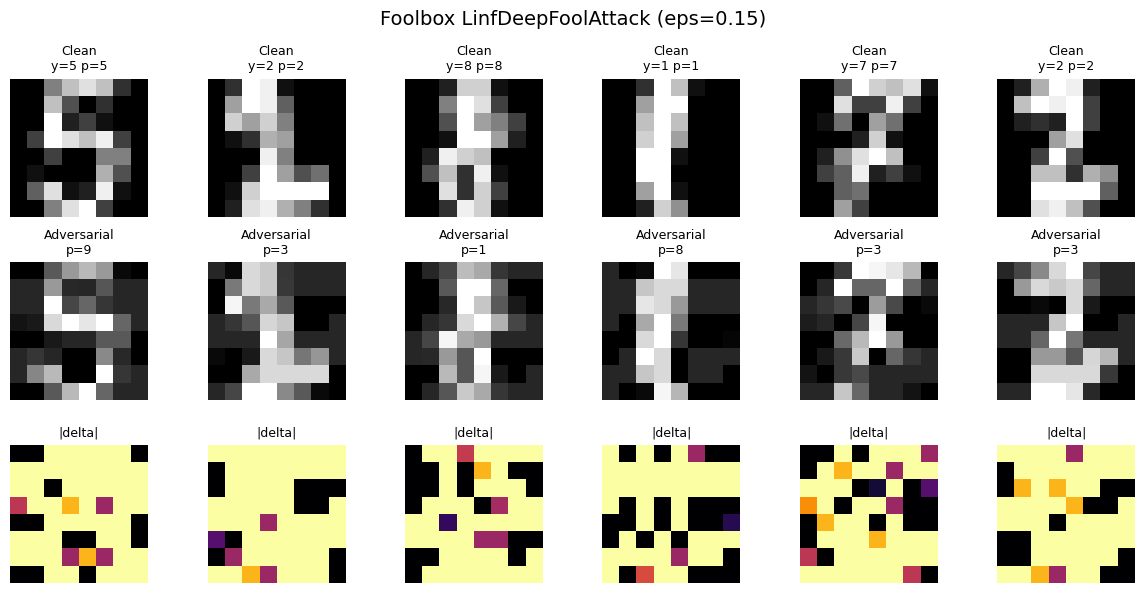

In [30]:
# ── Challenge 3: True black-box attack using Foolbox ───────────────────────
# Uncomment the next line to install if Foolbox is not present:
# !pip install foolbox -q

try:
    import foolbox as fb
    FOOLBOX_AVAILABLE = True
    print(f'Foolbox version: {fb.__version__}')
except ImportError:
    FOOLBOX_AVAILABLE = False
    print('Foolbox not installed. Run: pip install foolbox')

if FOOLBOX_AVAILABLE:
    # Wrap the Keras model for Foolbox (pixel values in [0, 1])
    fmodel = fb.TensorFlowModel(model, bounds=(0.0, 1.0))

    N_BB  = 30   # use a subset for speed
    X_bb  = to_4d(X_test[:N_BB]).astype(np.float32)
    y_bb  = y_test[:N_BB].astype(np.int32)
    images_fb = tf.constant(X_bb)
    labels_fb = tf.constant(y_bb)

    # LinfDeepFoolAttack: iterative minimal-perturbation attack (Foolbox built-in)
    attack    = fb.attacks.LinfDeepFoolAttack(steps=50)
    epsilons  = [0.05, 0.10, 0.15, 0.20]
    try:
        _, clipped_advs, success = attack(fmodel, images_fb, labels_fb, epsilons=epsilons)
    except AttributeError as e:
        if "np.find_common_type" not in str(e):
            raise
        print("Foolbox/NumPy 2.x compatibility issue detected. Using PGD fallback for this run.")

        clipped_advs = []
        success_flags = []
        for eps in epsilons:
            x_adv_eps = pgd_attack(
                model, X_bb, y_bb,
                eps=eps, alpha=max(eps / 4, 1e-3),
                steps=20, random_start=True
            ).astype(np.float32)

            preds_eps = predict_classes(model, x_adv_eps)
            success_flags.append(preds_eps != y_bb)  # True => attack succeeded
            clipped_advs.append(tf.convert_to_tensor(x_adv_eps, dtype=tf.float32))

        success = tf.convert_to_tensor(np.stack(success_flags, axis=0))

    print('\n=== Foolbox LinfDeepFoolAttack results ===')
    rows_fb = []
    for eps, s in zip(epsilons, success):
        sr  = float(s.numpy().mean())
        acc = 1.0 - sr
        rows_fb.append({'epsilon': eps, 'attack success rate': sr, 'robust accuracy': acc})
        print(f'  eps={eps:.2f}  success={sr:.4f}  robust_acc={acc:.4f}')

    fb_df = pd.DataFrame(rows_fb)

    # Compare with our manual PGD on the same subset
    manual_pgd_acc = robust_accuracy(model, X_test[:N_BB], y_test[:N_BB],
                                     attack_fn=pgd_attack, eps=0.15,
                                     alpha=0.03, steps=20, random_start=True)
    print(f'\nManual PGD (eps=0.15) robust acc on same {N_BB} samples: {manual_pgd_acc:.4f}')
    print('(Foolbox result should be similar to or stronger than our manual PGD)')

    # Visualise Foolbox adversarial examples at eps=0.15 (index 2)
    show_clean_vs_adv(model, X_test[:6], y_test[:6],
                      clipped_advs[2].numpy()[:6],
                      title='Foolbox LinfDeepFoolAttack (eps=0.15)')
    fb_df

---
## Challenge 4 — Preprocessing Defence Comparison

Implement Gaussian blur and a simulated JPEG-like block quantization alongside the existing smoothing and quantization defences. Compare all four on clean accuracy and robust accuracy at $\epsilon = 0.15$.

Defence                     Clean acc    FGSM acc     PGD acc
--------------------------------------------------------------
No defence                     0.9806      0.2222      0.1417
Avg-pool smoothing             0.8139      0.2500      0.2611
Quantization                   0.9722      0.5278      0.5278
Gaussian blur                  0.9194      0.2361      0.2111
JPEG simulation                0.9778      0.2389      0.1889


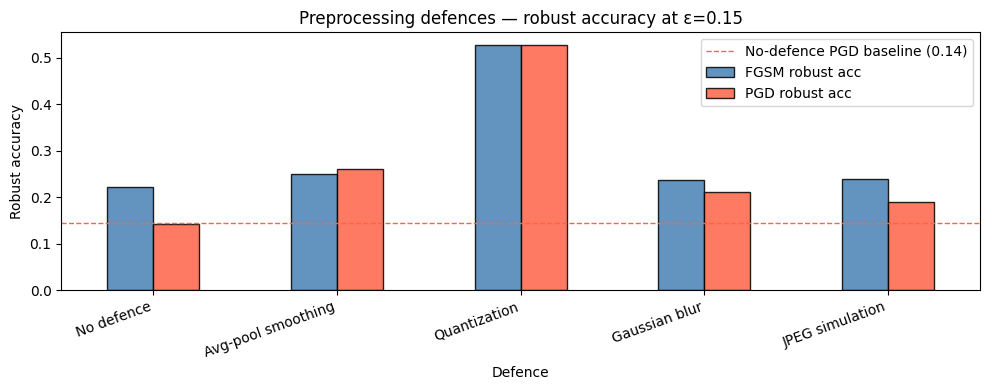

,Clean acc,FGSM robust acc,PGD robust acc
Defence,,,
No defence,0.980556,0.222222,0.141667
Avg-pool smoothing,0.813889,0.250000,0.261111
Quantization,0.972222,0.527778,0.527778
Gaussian blur,0.919444,0.236111,0.211111
JPEG simulation,0.977778,0.238889,0.188889


In [31]:
# ── Challenge 4: Extended preprocessing defence comparison ─────────────────
from scipy.ndimage import gaussian_filter


def preprocess_gaussian(x, sigma=0.8):
    """Gaussian blur — low-pass filter, models JPEG blur artefact."""
    x4 = to_4d(x)
    out = np.stack(
        [gaussian_filter(x4[i, :, :, 0], sigma=sigma) for i in range(len(x4))],
        axis=0
    )
    return np.clip(out[:, :, :, np.newaxis], 0.0, 1.0).astype(np.float32)


def preprocess_jpeg_sim(x, quality_levels=8):
    """
    Simulated JPEG-like compression:
    Divide the image into 4×4 blocks and quantize each block's values.
    Mimics DCT-domain quantization effects at coarse quality.
    """
    x4  = to_4d(x).copy()
    blk = 4
    h, w = x4.shape[1], x4.shape[2]
    for bi in range(h // blk):
        for bj in range(w // blk):
            patch = x4[:, bi*blk:(bi+1)*blk, bj*blk:(bj+1)*blk, :]
            x4[:, bi*blk:(bi+1)*blk, bj*blk:(bj+1)*blk, :] = (
                np.round(patch * (quality_levels - 1)) / (quality_levels - 1)
            )
    return np.clip(x4, 0.0, 1.0).astype(np.float32)


# ── Registry of all preprocessing functions ───────────────────────────────
preprocess_registry = {
    'No defence':          None,
    'Avg-pool smoothing':  preprocess_smooth,
    'Quantization':        preprocess_quantize,
    'Gaussian blur':       preprocess_gaussian,
    'JPEG simulation':     preprocess_jpeg_sim,
}

EPS_EVAL = 0.15
rows_prep = []

print(f'{"Defence":<25}  {"Clean acc":>10}  {"FGSM acc":>10}  {"PGD acc":>10}')
print('-' * 62)
for name, fn in preprocess_registry.items():
    clean_r = float(np.mean(defended_predict(model, X_test, fn) == y_test))
    fgsm_r  = robust_accuracy_with_preprocessing(
        model, X_test, y_test, fgsm_attack,
        preprocess_fn=fn, eps=EPS_EVAL)
    pgd_r   = robust_accuracy_with_preprocessing(
        model, X_test, y_test, pgd_attack,
        preprocess_fn=fn, eps=EPS_EVAL,
        alpha=EPS_EVAL / 4, steps=20, random_start=True)
    rows_prep.append({'Defence': name,
                      'Clean acc': clean_r,
                      'FGSM robust acc': fgsm_r,
                      'PGD robust acc': pgd_r})
    print(f'{name:<25}  {clean_r:>10.4f}  {fgsm_r:>10.4f}  {pgd_r:>10.4f}')

prep_df = pd.DataFrame(rows_prep).set_index('Defence')

# ── Bar chart ──────────────────────────────────────────────────────────────
prep_df[['FGSM robust acc', 'PGD robust acc']].plot(
    kind='bar', figsize=(10, 4), alpha=0.85, edgecolor='black',
    color=['steelblue', 'tomato'])
plt.axhline(pgd_accs[3], color='tomato', linestyle='--', linewidth=1,
            label=f'No-defence PGD baseline ({pgd_accs[3]:.2f})')
plt.title(f'Preprocessing defences — robust accuracy at ε={EPS_EVAL}')
plt.ylabel('Robust accuracy')
plt.xticks(rotation=20, ha='right')
plt.legend(); plt.tight_layout(); plt.show()

prep_df

---
## Challenge 5 — Export Robustness Data for a Report

Save all robustness results to a CSV file and export the complete multi-model robustness curve as a publication-ready PNG figure.

Saved CSV  → /home/abdeslem/Folders/2CS/S2/MLA/TPs/TP9_AML/report/robustness_results.csv
 epsilon  standard_fgsm_acc  standard_pgd_acc  pgd_at_fgsm_acc  pgd_at_pgd_acc  fgsm_at_fgsm_acc  fgsm_at_pgd_acc  smooth_defence_fgsm_acc  smooth_defence_pgd_acc
    0.00           0.980556          0.980556         0.975000        0.975000          0.983333         0.983333                 0.813889                0.813889
    0.05           0.858333          0.858333         0.950000        0.950000          0.944444         0.944444                 0.641667                0.650000
    0.10           0.588889          0.569444         0.869444        0.858333          0.869444         0.852778                 0.469444                0.444444
    0.15           0.222222          0.144444         0.713889        0.650000          0.691667         0.644444                 0.250000                0.266667
    0.20           0.091667          0.016667         0.433333        0.294444          0.452778

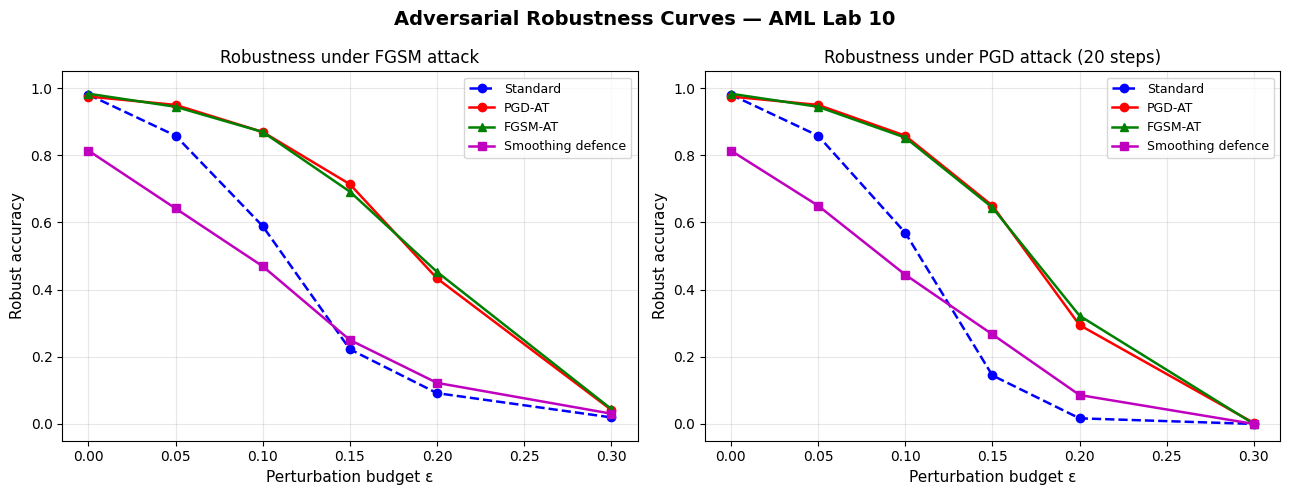

Saved PNG  → /home/abdeslem/Folders/2CS/S2/MLA/TPs/TP9_AML/report/robustness_curves.png
Saved CSV  → /home/abdeslem/Folders/2CS/S2/MLA/TPs/TP9_AML/report/model_comparison.csv


,Model,Clean accuracy,FGSM acc ε=0.15,PGD acc ε=0.15
0,Standard,0.980556,0.222222,0.144444
1,FGSM-AT,0.983333,0.691667,0.644444
2,PGD-AT,0.975000,0.713889,0.650000


In [32]:
# ── Challenge 5: Export robustness data to CSV and PNG ─────────────────────
import os

REPORT_DIR = os.path.join(os.path.dirname(os.path.abspath('__file__')), 'report')
os.makedirs(REPORT_DIR, exist_ok=True)

# ── Build comprehensive DataFrame ─────────────────────────────────────────
export_df = pd.DataFrame({
    'epsilon':                   EPSILONS,
    'standard_fgsm_acc':         fgsm_accs,
    'standard_pgd_acc':          pgd_accs,
    'pgd_at_fgsm_acc':           adv_fgsm_accs,
    'pgd_at_pgd_acc':            adv_pgd_accs,
    'fgsm_at_fgsm_acc':          fgsm_at_fgsm_accs,
    'fgsm_at_pgd_acc':           fgsm_at_pgd_accs,
    'smooth_defence_fgsm_acc':   pre_fgsm,
    'smooth_defence_pgd_acc':    pre_pgd,
})

csv_path = os.path.join(REPORT_DIR, 'robustness_results.csv')
export_df.to_csv(csv_path, index=False)
print(f'Saved CSV  → {csv_path}')
print(export_df.to_string(index=False))

# ── Robustness curve figure (publication-ready) ───────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=False)

# Left: FGSM robustness
axes[0].plot(EPSILONS, fgsm_accs,         'b--o', lw=1.8, label='Standard')
axes[0].plot(EPSILONS, adv_fgsm_accs,     'r-o',  lw=1.8, label='PGD-AT')
axes[0].plot(EPSILONS, fgsm_at_fgsm_accs, 'g-^',  lw=1.8, label='FGSM-AT')
axes[0].plot(EPSILONS, pre_fgsm,          'm-s',  lw=1.8, label='Smoothing defence')
axes[0].set_title('Robustness under FGSM attack', fontsize=12)
axes[0].set_xlabel('Perturbation budget ε', fontsize=11)
axes[0].set_ylabel('Robust accuracy', fontsize=11)
axes[0].set_ylim(-0.05, 1.05)
axes[0].grid(alpha=0.3); axes[0].legend(fontsize=9)

# Right: PGD robustness
axes[1].plot(EPSILONS, pgd_accs,          'b--o', lw=1.8, label='Standard')
axes[1].plot(EPSILONS, adv_pgd_accs,      'r-o',  lw=1.8, label='PGD-AT')
axes[1].plot(EPSILONS, fgsm_at_pgd_accs,  'g-^',  lw=1.8, label='FGSM-AT')
axes[1].plot(EPSILONS, pre_pgd,           'm-s',  lw=1.8, label='Smoothing defence')
axes[1].set_title('Robustness under PGD attack (20 steps)', fontsize=12)
axes[1].set_xlabel('Perturbation budget ε', fontsize=11)
axes[1].set_ylabel('Robust accuracy', fontsize=11)
axes[1].set_ylim(-0.05, 1.05)
axes[1].grid(alpha=0.3); axes[1].legend(fontsize=9)

fig.suptitle('Adversarial Robustness Curves — AML Lab 10',
             fontsize=14, fontweight='bold')
plt.tight_layout()

png_path = os.path.join(REPORT_DIR, 'robustness_curves.png')
plt.savefig(png_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved PNG  → {png_path}')

# ── Accuracy–robustness summary table ─────────────────────────────────────
summary_export = pd.DataFrame({
    'Model':               ['Standard', 'FGSM-AT', 'PGD-AT'],
    'Clean accuracy':      [clean_acc,  fgsm_at_clean, adv_clean_acc],
    'FGSM acc ε=0.15':     [fgsm_accs[3], fgsm_at_fgsm_accs[3], adv_fgsm_accs[3]],
    'PGD  acc ε=0.15':     [pgd_accs[3],  fgsm_at_pgd_accs[3],  adv_pgd_accs[3]],
})
summary_csv = os.path.join(REPORT_DIR, 'model_comparison.csv')
summary_export.to_csv(summary_csv, index=False)
print(f'Saved CSV  → {summary_csv}')
summary_export